In [2]:
"""
Synthetic Credit Card Fraud Detection Dataset Generator
Using only built-in Python libraries (no Faker dependency)
"""

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import string

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Configuration
NUM_TRANSACTIONS = 50000
FRAUD_PERCENTAGE = 0.02  # 2% fraud rate (realistic)

# Data for realistic generation
CITIES = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia',
          'San Antonio', 'San Diego', 'Dallas', 'San Jose', 'Austin', 'Jacksonville',
          'Fort Worth', 'Columbus', 'Charlotte', 'San Francisco', 'Indianapolis', 'Seattle',
          'Denver', 'Boston', 'Miami', 'Atlanta', 'Detroit', 'Portland', 'Las Vegas']

COUNTRIES = ['USA', 'Canada', 'Mexico', 'UK', 'Germany', 'France', 'Italy', 'Spain',
             'Russia', 'China', 'Japan', 'Brazil', 'India', 'Nigeria', 'Indonesia']

MERCHANT_CATEGORIES = [
    'Grocery', 'Gas Station', 'Restaurant', 'Online Shopping',
    'Electronics', 'Travel', 'Healthcare', 'Entertainment',
    'Clothing', 'Home Improvement', 'Insurance', 'Utilities',
    'Jewelry', 'Luxury Goods'
]

DEVICE_TYPES = ['Mobile', 'Desktop', 'POS Terminal']

DAYS_OF_WEEK = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

def generate_card_number():
    """Generate a simple card number format"""
    return ''.join([str(random.randint(0, 9)) for _ in range(16)])

def generate_customer_id(num):
    """Generate customer ID"""
    return f"CUST_{num:06d}"

def weighted_choice(choices, weights):
    """Make a weighted random choice"""
    total = sum(weights)
    r = random.uniform(0, total)
    upto = 0
    for choice, weight in zip(choices, weights):
        if upto + weight >= r:
            return choice
        upto += weight
    return choices[-1]

def generate_legitimate_transaction(idx, customer_ids, start_date):
    """Generate a legitimate transaction"""
    customer_id = random.choice(customer_ids)

    # Random timestamp
    random_days = random.randint(0, 365)
    random_seconds = random.randint(0, 86400)
    timestamp = start_date + timedelta(days=random_days, seconds=random_seconds)

    # Merchant category
    merchant_category = random.choice(MERCHANT_CATEGORIES[:12])  # Exclude Jewelry, Luxury Goods

    # Transaction amount based on category
    if merchant_category in ['Grocery', 'Gas Station']:
        amount = round(np.random.gamma(2, 25), 2)
    elif merchant_category in ['Restaurant', 'Entertainment']:
        amount = round(np.random.gamma(2, 20), 2)
    elif merchant_category in ['Electronics', 'Travel']:
        amount = round(np.random.gamma(3, 100), 2)
    elif merchant_category == 'Online Shopping':
        amount = round(np.random.gamma(2, 30), 2)
    else:
        amount = round(np.random.gamma(2, 35), 2)

    amount = max(amount, 1.0)

    # Card number
    card_number = generate_card_number()

    # Location - mostly USA
    location = random.choice(CITIES)
    country = 'USA' if random.random() < 0.9 else random.choice(['Canada', 'Mexico'])

    # Device type
    device_type = weighted_choice(DEVICE_TYPES, [0.4, 0.3, 0.3])

    # Hour and day
    hour = timestamp.hour
    day_of_week = DAYS_OF_WEEK[timestamp.weekday()]

    return {
        'transaction_id': f"TXN_{idx:08d}",
        'customer_id': customer_id,
        'card_number': card_number,
        'timestamp': timestamp,
        'amount': amount,
        'merchant_category': merchant_category,
        'location': location,
        'country': country,
        'device_type': device_type,
        'hour': hour,
        'day_of_week': day_of_week,
        'is_fraud': 0
    }

def generate_fraudulent_transaction(idx, customer_ids, start_date):
    """Generate a fraudulent transaction"""
    customer_id = random.choice(customer_ids)

    # Random timestamp
    random_days = random.randint(0, 365)
    random_seconds = random.randint(0, 86400)
    timestamp = start_date + timedelta(days=random_days, seconds=random_seconds)

    # Fraud-prone categories
    merchant_category = weighted_choice(
        ['Electronics', 'Online Shopping', 'Travel', 'Jewelry', 'Luxury Goods'],
        [0.3, 0.3, 0.2, 0.1, 0.1]
    )

    # Higher amounts for fraud
    amount = round(np.random.gamma(4, 150), 2)
    amount = max(amount, 50.0)

    # Card number
    card_number = generate_card_number()

    # Location - often international
    if random.random() < 0.5:
        location = random.choice(CITIES)
        country = random.choice(['Russia', 'Nigeria', 'China', 'Brazil', 'Indonesia'])
    else:
        location = random.choice(CITIES)
        country = 'USA'

    # Device type - mostly online
    device_type = weighted_choice(DEVICE_TYPES, [0.5, 0.45, 0.05])

    # Unusual hours (weighted towards night)
    hour_weights = [2, 2, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1,
                   1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2]
    hour = weighted_choice(list(range(24)), hour_weights)

    # Day of week
    day_of_week = DAYS_OF_WEEK[timestamp.weekday()]

    return {
        'transaction_id': f"TXN_F_{idx:08d}",
        'customer_id': customer_id,
        'card_number': card_number,
        'timestamp': timestamp,
        'amount': amount,
        'merchant_category': merchant_category,
        'location': location,
        'country': country,
        'device_type': device_type,
        'hour': hour,
        'day_of_week': day_of_week,
        'is_fraud': 1
    }

def generate_dataset(num_transactions, fraud_percentage):
    """Generate the complete dataset"""
    num_fraud = int(num_transactions * fraud_percentage)
    num_legitimate = num_transactions - num_fraud

    # Generate customer IDs pool
    customer_ids = [generate_customer_id(i) for i in range(10000)]

    start_date = datetime(2024, 1, 1)

    data = []

    print(f"Generating {num_legitimate} legitimate transactions...")
    for i in range(num_legitimate):
        if i % 10000 == 0:
            print(f"  Progress: {i}/{num_legitimate}")
        data.append(generate_legitimate_transaction(i, customer_ids, start_date))

    print(f"Generating {num_fraud} fraudulent transactions...")
    for i in range(num_fraud):
        if i % 200 == 0:
            print(f"  Progress: {i}/{num_fraud}")
        data.append(generate_fraudulent_transaction(i, customer_ids, start_date))

    return data

def add_engineered_features(df):
    """Add additional engineered features"""
    print("Adding engineered features...")

    # Sort by customer and timestamp
    df = df.sort_values(['customer_id', 'timestamp']).reset_index(drop=True)

    # Calculate customer statistics
    print("  - Customer average amount...")
    df['customer_avg_amount'] = df.groupby('customer_id')['amount'].transform('mean')

    # Deviation from customer's average
    print("  - Amount deviation...")
    df['amount_deviation'] = (df['amount'] - df['customer_avg_amount']) / (df['customer_avg_amount'] + 1)

    # Weekend flag
    print("  - Weekend flag...")
    df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

    # Night transaction (10PM - 6AM)
    print("  - Night transaction flag...")
    df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 22 or x <= 6 else 0)

    # International transaction
    print("  - International flag...")
    df['is_international'] = (df['country'] != 'USA').astype(int)

    # Transaction count per customer
    print("  - Transaction count per customer...")
    df['transaction_count'] = df.groupby('customer_id').cumcount() + 1

    return df

# Main execution
print(f"=" * 60)
print(f"SYNTHETIC CREDIT CARD FRAUD DETECTION DATASET GENERATOR")
print(f"=" * 60)
print(f"\nGenerating {NUM_TRANSACTIONS:,} transactions...")
print(f"Fraud rate: {FRAUD_PERCENTAGE*100}%\n")

# Generate transactions
transactions = generate_dataset(NUM_TRANSACTIONS, FRAUD_PERCENTAGE)

# Convert to DataFrame
print("\nConverting to DataFrame...")
df = pd.DataFrame(transactions)

# Add engineered features
df = add_engineered_features(df)

# Shuffle the dataset
print("Shuffling dataset...")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
output_file = 'credit_card_fraud_dataset.csv'
print(f"\nSaving to {output_file}...")
df.to_csv(output_file, index=False)

# Display statistics
print(f"\n" + "=" * 60)
print(f"✅ DATASET GENERATED SUCCESSFULLY!")
print(f"=" * 60)
print(f"\n📊 DATASET STATISTICS:")
print(f"-" * 60)
print(f"Total Transactions:      {len(df):,}")
print(f"Legitimate Transactions: {len(df[df['is_fraud'] == 0]):,}")
print(f"Fraudulent Transactions: {len(df[df['is_fraud'] == 1]):,}")
print(f"Fraud Percentage:        {(df['is_fraud'].sum() / len(df)) * 100:.2f}%")
print(f"\n📋 COLUMNS ({len(df.columns)}):")
print(f"-" * 60)
for col in df.columns:
    print(f"  • {col}")

print(f"\n💰 AMOUNT STATISTICS:")
print(f"-" * 60)
print(df.groupby('is_fraud')['amount'].describe())

print(f"\n🏪 FRAUD BY MERCHANT CATEGORY:")
print(f"-" * 60)
fraud_by_category = df.groupby('merchant_category')['is_fraud'].agg(['count', 'sum', 'mean'])
fraud_by_category.columns = ['Total', 'Frauds', 'Fraud_Rate']
fraud_by_category['Fraud_Rate'] = fraud_by_category['Fraud_Rate'] * 100
print(fraud_by_category.sort_values('Fraud_Rate', ascending=False))

print(f"\n📱 FRAUD BY DEVICE TYPE:")
print(f"-" * 60)
fraud_by_device = df.groupby('device_type')['is_fraud'].agg(['count', 'sum', 'mean'])
fraud_by_device.columns = ['Total', 'Frauds', 'Fraud_Rate']
fraud_by_device['Fraud_Rate'] = fraud_by_device['Fraud_Rate'] * 100
print(fraud_by_device)

print(f"\n🌍 FRAUD BY COUNTRY (Top 10):")
print(f"-" * 60)
fraud_by_country = df.groupby('country')['is_fraud'].agg(['count', 'sum', 'mean'])
fraud_by_country.columns = ['Total', 'Frauds', 'Fraud_Rate']
fraud_by_country['Fraud_Rate'] = fraud_by_country['Fraud_Rate'] * 100
print(fraud_by_country.sort_values('Frauds', ascending=False).head(10))

print(f"\n🔍 SAMPLE DATA (First 10 rows):")
print(f"-" * 60)
print(df.head(10).to_string())

print(f"\n" + "=" * 60)
print(f"Dataset saved to: {output_file}")
print(f"=" * 60)

SYNTHETIC CREDIT CARD FRAUD DETECTION DATASET GENERATOR

Generating 50,000 transactions...
Fraud rate: 2.0%

Generating 49000 legitimate transactions...
  Progress: 0/49000
  Progress: 10000/49000
  Progress: 20000/49000
  Progress: 30000/49000
  Progress: 40000/49000
Generating 1000 fraudulent transactions...
  Progress: 0/1000
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000

Converting to DataFrame...
Adding engineered features...
  - Customer average amount...
  - Amount deviation...
  - Weekend flag...
  - Night transaction flag...
  - International flag...
  - Transaction count per customer...
Shuffling dataset...

Saving to credit_card_fraud_dataset.csv...

✅ DATASET GENERATED SUCCESSFULLY!

📊 DATASET STATISTICS:
------------------------------------------------------------
Total Transactions:      50,000
Legitimate Transactions: 49,000
Fraudulent Transactions: 1,000
Fraud Percentage:        2.00%

📋 COLUMNS (18):
-------------------------------

In [3]:
import pandas as pd

df = pd.read_csv("credit_card_fraud_dataset.csv")

print(df.shape)
df.head()


(50000, 18)


,transaction_id,customer_id,card_number,timestamp,amount,merchant_category,location,country,device_type,hour,day_of_week,is_fraud,customer_avg_amount,amount_deviation,is_weekend,is_night,is_international,transaction_count
0,TXN_00012212,CUST_006749,5996138290773037,2024-08-06 20:11:33,5.69,Grocery,San Diego,USA,POS Terminal,20,Tuesday,0,46.815000,-0.860086,0,0,0,2
1,TXN_00014438,CUST_001870,1330140563148576,2024-03-14 03:25:53,65.83,Grocery,Indianapolis,USA,Mobile,3,Thursday,0,85.020000,-0.223088,0,1,0,3
2,TXN_00016879,CUST_000039,1833897061732475,2024-08-17 11:52:43,32.03,Entertainment,Miami,USA,Desktop,11,Saturday,0,51.836000,-0.374858,1,0,0,1
3,TXN_00013779,CUST_002457,6082322879328374,2024-09-27 19:08:27,46.39,Gas Station,Seattle,USA,Mobile,19,Friday,0,121.139000,-0.611999,0,0,0,10
4,TXN_00025940,CUST_007916,1185856136543919,2024-05-22 14:28:16,30.44,Grocery,Fort Worth,USA,POS Terminal,14,Wednesday,0,114.714286,-0.728296,0,0,0,3


In [4]:
# Dataset structure
df.info()

# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       50000 non-null  object 
 1   customer_id          50000 non-null  object 
 2   card_number          50000 non-null  int64  
 3   timestamp            50000 non-null  object 
 4   amount               50000 non-null  float64
 5   merchant_category    50000 non-null  object 
 6   location             50000 non-null  object 
 7   country              50000 non-null  object 
 8   device_type          50000 non-null  object 
 9   hour                 50000 non-null  int64  
 10  day_of_week          50000 non-null  object 
 11  is_fraud             50000 non-null  int64  
 12  customer_avg_amount  50000 non-null  float64
 13  amount_deviation     50000 non-null  float64
 14  is_weekend           50000 non-null  int64  
 15  is_night             50000 non-null 

In [5]:
df = df.drop_duplicates()


In [6]:
cols_to_drop = [
    "transaction_id",
    "customer_id",
    "card_number",
    "timestamp"
]

df = df.drop(columns=cols_to_drop)


In [7]:
# STEP 3: Feature Engineering
# ===============================

# 3.1 Transaction amount relative to customer average
df["amount_ratio"] = df["amount"] / (df["customer_avg_amount"] + 1)

# 3.2 High transaction flag
df["is_high_amount"] = (df["amount"] > df["customer_avg_amount"]).astype(int)

# 3.3 High frequency customer flag
df["is_high_frequency"] = (df["transaction_count"] > 10).astype(int)

# 3.4 Risky time window (late night / early morning)
df["is_risky_hour"] = df["hour"].apply(
    lambda x: 1 if (x >= 0 and x <= 5) else 0
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [8]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]


In [9]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))


Categorical Columns: ['merchant_category', 'location', 'country', 'device_type', 'day_of_week']
Numerical Columns: ['amount', 'hour', 'customer_avg_amount', 'amount_deviation', 'is_weekend', 'is_night', 'is_international', 'transaction_count', 'amount_ratio', 'is_high_amount', 'is_high_frequency', 'is_risky_hour']


In [10]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [14]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)


In [15]:
print(X.shape)
print(X.isnull().sum().sum())


(50000, 64)
0


In [16]:
cleaned_df = pd.concat([X, y], axis=1)

cleaned_df.to_csv("cleaned_fraud_dataset.csv", index=False)


In [18]:
!pip install matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("credit_card_fraud_dataset.csv")

df.head()


  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
     -------------------------------------- 294.9/294.9 kB 6.1 MB/s eta 0:00:00
     ---------------------------------------- 73.4/73.4 kB ? eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 16.4 MB/s eta 0:00:00
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     -------------------------------------- 122.8/122.8 kB 7.5 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,transaction_id,customer_id,card_number,timestamp,amount,merchant_category,location,country,device_type,hour,day_of_week,is_fraud,customer_avg_amount,amount_deviation,is_weekend,is_night,is_international,transaction_count
0,TXN_00012212,CUST_006749,5996138290773037,2024-08-06 20:11:33,5.69,Grocery,San Diego,USA,POS Terminal,20,Tuesday,0,46.815000,-0.860086,0,0,0,2
1,TXN_00014438,CUST_001870,1330140563148576,2024-03-14 03:25:53,65.83,Grocery,Indianapolis,USA,Mobile,3,Thursday,0,85.020000,-0.223088,0,1,0,3
2,TXN_00016879,CUST_000039,1833897061732475,2024-08-17 11:52:43,32.03,Entertainment,Miami,USA,Desktop,11,Saturday,0,51.836000,-0.374858,1,0,0,1
3,TXN_00013779,CUST_002457,6082322879328374,2024-09-27 19:08:27,46.39,Gas Station,Seattle,USA,Mobile,19,Friday,0,121.139000,-0.611999,0,0,0,10
4,TXN_00025940,CUST_007916,1185856136543919,2024-05-22 14:28:16,30.44,Grocery,Fort Worth,USA,POS Terminal,14,Wednesday,0,114.714286,-0.728296,0,0,0,3


In [19]:
fraud_counts = df["is_fraud"].value_counts()
fraud_percent = df["is_fraud"].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_percent)


is_fraud
0    49000
1     1000
Name: count, dtype: int64
is_fraud
0    98.0
1     2.0
Name: proportion, dtype: float64


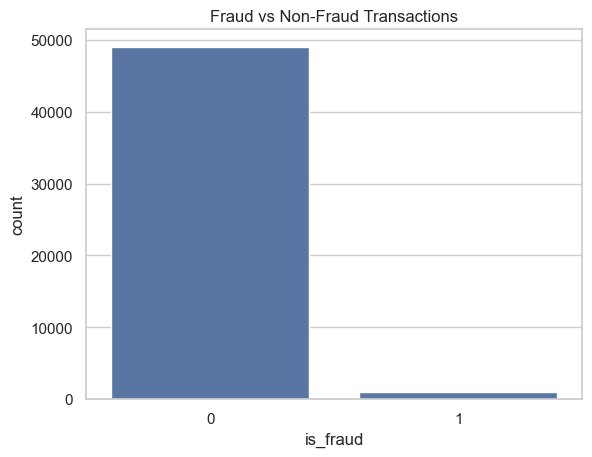

In [20]:
plt.figure()
sns.countplot(x="is_fraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


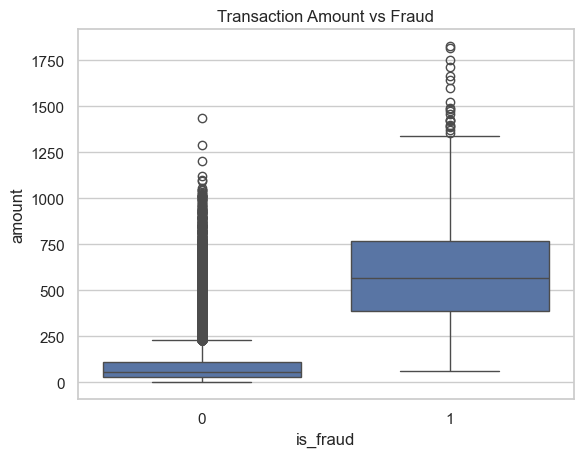

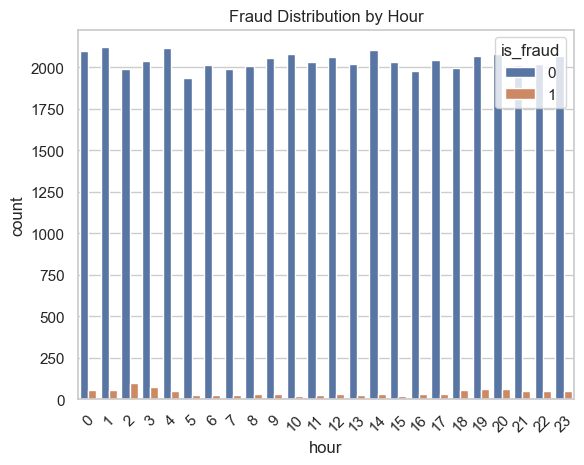

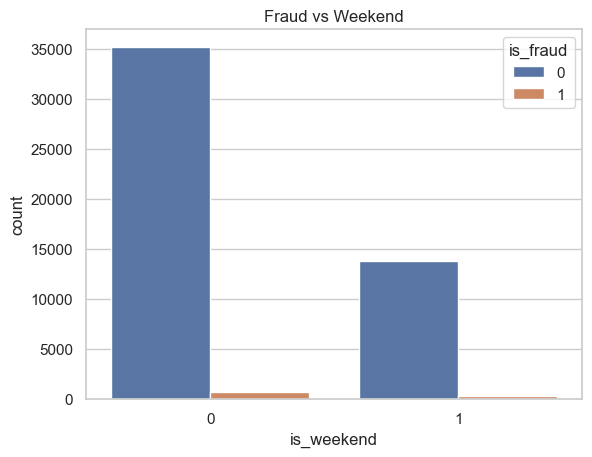

In [21]:
df["amount"].describe()
plt.figure()
sns.boxplot(x="is_fraud", y="amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

plt.figure()
sns.countplot(x="hour", hue="is_fraud", data=df)
plt.title("Fraud Distribution by Hour")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.countplot(x="is_weekend", hue="is_fraud", data=df)
plt.title("Fraud vs Weekend")
plt.show()


In [22]:
import pandas as pd

# Load cleaned & preprocessed dataset
df = pd.read_csv("cleaned_fraud_dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (50000, 65)


,amount,hour,customer_avg_amount,amount_deviation,is_weekend,is_night,is_international,transaction_count,amount_ratio,is_high_amount,...,country_USA,device_type_Mobile,device_type_POS Terminal,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,is_fraud
0,-0.711027,1.224560,-0.974971,-0.951925,-0.626704,-0.779363,-0.344083,-0.701910,-0.961394,-0.753095,...,True,False,True,False,False,False,False,True,False,0
1,-0.298642,-1.218943,-0.379631,-0.246909,-0.626704,1.283099,-0.344083,-0.234979,-0.246126,-0.753095,...,True,True,False,False,False,False,True,False,False,0
2,-0.530412,-0.069059,-0.896730,-0.414885,1.595650,-0.779363,-0.344083,-1.168842,-0.422176,-0.753095,...,True,False,False,False,True,False,False,False,False,0
3,-0.431944,1.080825,0.183204,-0.677348,-0.626704,-0.779363,-0.344083,3.033542,-0.672744,-0.753095,...,True,True,False,False,False,False,False,False,False,0
4,-0.541314,0.362147,0.083089,-0.806063,-0.626704,-0.779363,-0.344083,-0.234979,-0.801956,-0.753095,...,True,False,True,False,False,False,False,False,True,0


In [23]:
import pandas as pd

# Load cleaned & preprocessed dataset
df = pd.read_csv("cleaned_fraud_dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (50000, 65)


,amount,hour,customer_avg_amount,amount_deviation,is_weekend,is_night,is_international,transaction_count,amount_ratio,is_high_amount,...,country_USA,device_type_Mobile,device_type_POS Terminal,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,is_fraud
0,-0.711027,1.224560,-0.974971,-0.951925,-0.626704,-0.779363,-0.344083,-0.701910,-0.961394,-0.753095,...,True,False,True,False,False,False,False,True,False,0
1,-0.298642,-1.218943,-0.379631,-0.246909,-0.626704,1.283099,-0.344083,-0.234979,-0.246126,-0.753095,...,True,True,False,False,False,False,True,False,False,0
2,-0.530412,-0.069059,-0.896730,-0.414885,1.595650,-0.779363,-0.344083,-1.168842,-0.422176,-0.753095,...,True,False,False,False,True,False,False,False,False,0
3,-0.431944,1.080825,0.183204,-0.677348,-0.626704,-0.779363,-0.344083,3.033542,-0.672744,-0.753095,...,True,True,False,False,False,False,False,False,False,0
4,-0.541314,0.362147,0.083089,-0.806063,-0.626704,-0.779363,-0.344083,-0.234979,-0.801956,-0.753095,...,True,False,True,False,False,False,False,False,True,0


In [24]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (50000, 64)
Target shape: (50000,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,
    stratify=y          # keeps fraud ratio same
)


In [26]:
print("Before SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))


Before SMOTE:
is_fraud
0    39200
1      800
Name: count, dtype: int64
is_fraud
0    0.98
1    0.02
Name: proportion, dtype: float64


In [28]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


  Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # let trees grow fully
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
rf_model.fit(X_train_sm, y_train_sm)
print("Random Forest model trained successfully!")


Random Forest model trained successfully!


In [30]:
# Predict class labels
y_test_pred = rf_model.predict(X_test)

# Predict fraud probabilities
y_test_prob = rf_model.predict_proba(X_test)[:, 1]


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[9765   35]
 [  49  151]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC Score:", roc_auc)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9800
           1       0.81      0.76      0.78       200

    accuracy                           0.99     10000
   macro avg       0.90      0.88      0.89     10000
weighted avg       0.99      0.99      0.99     10000

ROC-AUC Score: 0.9894647959183673


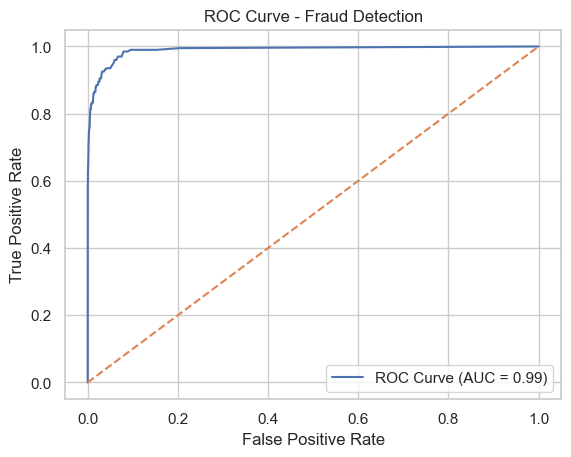

In [33]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()
plt.show()


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)


True Negatives: 9765
False Positives: 35
False Negatives: 49
True Positives: 151


In [35]:
import joblib

joblib.dump(rf_model, "fraud_random_forest_model.pkl")
joblib.dump(X_train.columns, "model_features.pkl")

print("✅ Model and feature list saved")


✅ Model and feature list saved


In [36]:
sample = X_test.iloc[[0]]

pred = rf_model.predict(sample)[0]
prob = rf_model.predict_proba(sample)[0][1]

print("Prediction:", "Fraud" if pred == 1 else "Normal")
print("Fraud Probability:", prob)


Prediction: Normal
Fraud Probability: 0.0


In [37]:
import joblib
import pandas as pd

# Load trained model
rf_model = joblib.load("fraud_random_forest_model.pkl")

# Load feature columns used during training
model_features = joblib.load("model_features.pkl")


In [38]:
new_transaction_raw = {
    "amount": 4500,
    "merchant_category": "Electronics",
    "location": "New York",
    "country": "USA",
    "device_type": "Mobile",
    "hour": 2,
    "day_of_week": "Sunday",
    "customer_avg_amount": 1200,
    "amount_deviation": 2.75,
    "is_weekend": 1,
    "is_night": 1,
    "is_international": 0,
    "transaction_count": 3
}
new_df = pd.DataFrame([new_transaction_raw])


In [39]:
# One-hot encode
new_df_encoded = pd.get_dummies(new_df)

# Add missing columns (if any)
for col in model_features:
    if col not in new_df_encoded.columns:
        new_df_encoded[col] = 0

# Keep only model features (correct order)
new_df_encoded = new_df_encoded[model_features]


In [40]:
prediction = rf_model.predict(new_df_encoded)[0]
probability = rf_model.predict_proba(new_df_encoded)[0][1]

print("Prediction:", "Fraud" if prediction == 1 else "Normal")
print("Fraud Probability:", round(probability, 3))


Prediction: Fraud
Fraud Probability: 0.525
